Empezando desde cero

In [59]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, BatchNormalization
from keras.optimizers import Adam

In [2]:
def import_dataset(asset='gc1', format='min'):
    file_path = f'../Data/{asset}{format}.txt'
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.lower()
    df = df.rename(columns={
        'vol': 'volume'
    })
    df['dtyyyymmdd'] = pd.to_datetime(df['dtyyyymmdd'], format='%Y%m%d')
    # Asegurar que time tenga 6 dígitos (HHMMSS) y convertir a tipo time
    df['time'] = df['time'].astype(str).str.zfill(6)
    df['time'] = pd.to_datetime(df['time'], format='%H%M%S').dt.time
    # Unir fecha y hora en una sola columna de tipo datetime
    df['datetime'] = pd.to_datetime(df['dtyyyymmdd'].astype(str) + ' ' + df['time'].astype(str))
    df = df.sort_values('datetime')
    print(f"Dataset '{asset}' imported with {len(df)} rows")
    specs = pd.read_json("../Data/futuros_specs.json")
    spec = specs[asset[:2].upper()]
    return df, spec

In [3]:
df_min, spec = import_dataset()

Dataset 'gc1' imported with 4565856 rows


In [4]:
def clean(df, asset='gc1'):
    df = df.copy()
    # 1. Eliminar Sábados (Día 5) - Ruido absoluto detectado en el EDA
    df = df[df['datetime'].dt.weekday != 5]
    # 2. Definir el inicio de la sesión (Trading Day)
    # En tus datos el hueco es de 00:00 a 01:00. 
    # Restamos 1 hora para que la vela de la 01:05 sea la primera del "día"
    df['trading_date'] = (df['datetime'] - pd.Timedelta(hours=1)).dt.date
    # 3. Filtrar el ruido del "Break" (15 min antes y 5 min después)
    # Minutos totales del día:
    minutes = df['datetime'].dt.hour * 60 + df['datetime'].dt.minute
    # Filtramos: antes de las 00:00 (cierre) y justo al abrir (01:00)
    # Esto elimina spreads gigantes que la LSTM no puede predecir
    mask_noise = (minutes >= 1425) | (minutes == 60) 
    df = df[~mask_noise]
    # 4. Eliminar duplicados y asegurar orden temporal
    df = df.drop_duplicates(subset=['datetime']).sort_values('datetime')
    # 5. Resetear índice para que la secuencia de la LSTM sea continua
    df = df.reset_index(drop=True)
    print(f"Limpieza {asset} completada. Filas restantes: {len(df)}")
    return df

In [5]:
df_min_clean = clean(df_min)

Limpieza gc1 completada. Filas restantes: 4518540


In [6]:
def resample_ohlcv(df, period="5min"):
    """
    Resamplea un dataframe OHLCV al periodo deseado.
    period puede ser: '1min', '5min', '15min', '30min', '1H', '1D', etc.
    """

    # Asegurar orden temporal
    df = df.sort_values("datetime").copy()

    # Asegurar que datetime es datetime64
    df["datetime"] = pd.to_datetime(df["datetime"])

    # Establecer índice temporal
    df = df.set_index("datetime")

    # Diccionario OHLCV estándar
    ohlc_dict = {
        "open": "first",
        "high": "max",
        "low": "min",
        "close": "last",
        "volume": "sum",
        "openint": "last"
    }

    # Resample usando el periodo elegido
    df_resampled = df.resample(period).agg(ohlc_dict)

    # Eliminar velas vacías
    df_resampled = df_resampled.dropna(subset=["open", "high", "low", "close"])

    # Añadir columnas extra
    df_resampled["ticker"] = df["ticker"].iloc[0]
    df_resampled["per"] = period

    # Reset index
    df_resampled = df_resampled.reset_index()

    return df_resampled

In [7]:
df_min_clean_5min = resample_ohlcv(df_min_clean, period="5min")

In [8]:
def daily_ohlcv_cummulative(df_5_min):
    df = df_5_min.copy()
    df = df.sort_values('datetime')
    # Usamos el desplazamiento de 1 hora que definimos en la limpieza
    df['trading_date'] = (df['datetime'] - pd.Timedelta(hours=1)).dt.date
    
    # Ahora agrupamos por 'trading_date' en lugar de 'date'
    df['open_day'] = df.groupby('trading_date')['open'].transform('first')
    df['high_cum'] = df.groupby('trading_date')['high'].cummax()
    df['low_cum'] = df.groupby('trading_date')['low'].cummin()
    df['volume_cum'] = df.groupby('trading_date')['volume'].cumsum()
    
    return df


In [9]:
df_min_clean_5min_with_cum = daily_ohlcv_cummulative(df_min_clean_5min)

In [13]:
df_min_clean_5min_with_cum.loc[0]

datetime        2010-09-20 07:00:00
open                         1279.8
high                         1280.7
low                          1279.8
close                        1279.8
volume                           72
openint                         0.0
ticker                           GC
per                            5min
trading_date             2010-09-20
open_day                     1279.8
high_cum                     1280.7
low_cum                      1279.8
volume_cum                       72
Name: 0, dtype: object

In [21]:
def add_time_features(df):
    """
    Calcula senos y cosenos para hora, minuto y día de la semana.
    También añade una bandera para las horas de alta volatilidad (Noticias/Apertura NY).
    """
    df = df.copy()
    
    # 1. Minutos del día (0 a 1439)
    df['minutes_total'] = df['datetime'].dt.hour * 60 + df['datetime'].dt.minute
    df['min_sin'] = np.sin(2 * np.pi * df['minutes_total'] / 1440)
    df['min_cos'] = np.cos(2 * np.pi * df['minutes_total'] / 1440)
    
    # 2. Hora del día (0 a 23)
    df['hour_sin'] = np.sin(2 * np.pi * df['datetime'].dt.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['datetime'].dt.hour / 24)
    
    # 3. Día de la semana (0 a 6)
    # Aunque ya filtramos sábados, mantenemos la base 7 para la coherencia del ciclo
    df['day_sin'] = np.sin(2 * np.pi * df['datetime'].dt.dayofweek / 7)
    df['day_cos'] = np.cos(2 * np.pi * df['datetime'].dt.dayofweek / 7)
    
    # 4. Feature de contexto: Apertura de Nueva York (Noticias Macro)
    # En tus datos (que parecen GMT), la apertura de NY suele ser 13:30-15:30
    # Ajusta estas horas según lo que viste en tu gráfico de volatilidad
    df['is_high_vol_hour'] = df['datetime'].dt.hour.isin([13, 14, 15]).astype(int)

    # Eliminamos la columna auxiliar
    df = df.drop(columns=['minutes_total'])
    
    return df

In [22]:
def add_tick_features(df, tick_size):
    df = df.copy()
    # Micro-estructura (Vela actual)
    df['body_ticks'] = (df['close'] - df['open']) / tick_size
    df['range_ticks'] = (df['high'] - df['low']) / tick_size
    df['upper_wick_ticks'] = (df['high'] - df[['open', 'close']].max(axis=1)) / tick_size
    df['lower_wick_ticks'] = (df[['open', 'close']].min(axis=1) - df['low']) / tick_size
    
    # Macro-contexto (Respecto al día)
    df['dist_high_cum_ticks'] = (df['high_cum'] - df['close']) / tick_size
    df['dist_low_cum_ticks'] = (df['close'] - df['low_cum']) / tick_size
    df['dist_open_day_ticks'] = (df['close'] - df['open_day']) / tick_size
    
    # Eficiencia de Volumen: ¿Cuántos contratos mueven 1 tick?
    df['vol_eff'] = df['volume'] / (df['range_ticks'] + 0.1)
    return df


In [34]:
def add_indicator_features(df):
    df = df.copy()
    # Log returns para estabilidad numérica
    df['log_ret'] = np.log(df['close'] / df['close'].shift(1))
    # Retorno acumulado a 15 minutos (3 velas de 5 min)
    df['target_ret_15m'] = np.log(df['close'].shift(-3) / df['close'])

    # Retorno acumulado a 30 minutos (6 velas de 5 min)
    df['target_ret_30m'] = np.log(df['close'].shift(-6) / df['close'])
    
    # RSI de 14 (Estándar)
    # Nota: Aquí puedes usar pandas_ta o ta-lib si los tienes
    # Si no, un RSI simple:
    delta = df['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['rsi_14'] = 100 - (100 / (1 + rs))
    
    # Distancia a la Media Móvil (SMA 20)
    df['sma_20'] = df['close'].rolling(window=20).mean()
    df['dist_sma_20_ticks'] = (df['close'] - df['sma_20']) / spec['tick_size']
    
    return df


In [35]:
def generate_features(df, spec):
    df = df.copy()
    
    # 1. Tiempo
    df = add_time_features(df)
    
    # 2. Ticks (usando tu spec)
    df = add_tick_features(df, spec['tick_size'])
    
    # 3. Indicadores
    df = add_indicator_features(df)
    
    # 4. Limpieza final de NaNs (creados por las medias móviles)
    df = df.dropna()
    
    return df


In [36]:
df_features = generate_features(df_min_clean_5min_with_cum, spec)

In [37]:
df_features.iloc[0]

datetime               2010-09-20 08:35:00
open                                1282.8
high                                1282.8
low                                 1281.9
close                               1282.0
volume                                 108
openint                                0.0
ticker                                  GC
per                                   5min
trading_date                    2010-09-20
open_day                            1279.8
high_cum                            1283.4
low_cum                             1279.8
volume_cum                            2405
future_ticks                           5.0
target                                   2
min_sin                           0.779884
min_cos                          -0.625923
hour_sin                          0.866025
hour_cos                              -0.5
day_sin                                0.0
day_cos                                1.0
is_high_vol_hour                         0
body_ticks 

In [38]:
def analyze_tick_volatility(df, tick_size):
    """
    Calcula el movimiento promedio en ticks para diferentes horizontes.
    Ayuda a decidir si predecir a 5, 15 o 30 minutos.
    """
    analysis = {}
    # Horizontes: 1 vela (5m), 3 velas (15m), 6 velas (30m), 12 velas (60m)
    horizons = [1, 3, 6, 12]
    
    for h in horizons:
        # Calculamos el valor absoluto del movimiento en ticks
        abs_tick_move = (df['close'].shift(-h) - df['close']).abs() / tick_size
        
        analysis[f'{h*5} min'] = {
            'mean_ticks': abs_tick_move.mean(),
            'median_ticks': abs_tick_move.median(),
            'std_ticks': abs_tick_move.std(),
            'p75_ticks': abs_tick_move.quantile(0.75) # El 25% de las veces se mueve más de esto
        }
    
    return pd.DataFrame(analysis).T

# 1. Ejecutar análisis (usa tu 'spec' cargado)
vol_stats = analyze_tick_volatility(df_features, spec['tick_size'])
print("Análisis de Volatilidad en Ticks:")
print(vol_stats)

# 2. Lógica de decisión para el TARGET
# Si el costo (spread + comisión) es ~2 ticks, buscamos un horizonte 
# donde la media sea al menos 3-4 veces ese costo.
avg_5m = vol_stats.loc['5 min', 'mean_ticks']
avg_15m = vol_stats.loc['15 min', 'mean_ticks']

if avg_5m < 3:
    print(f"\n[!] Cuidado: A 5 min el movimiento promedio ({avg_5m:.2f} ticks) es muy bajo.")
    print(f"Recomendado: Usar 15 min ({avg_15m:.2f} ticks) para el target de la LSTM.")

# 3. Implementación del Target sugerido (ejemplo 15 min)
HORIZONTE = 3 # velas de 5 min
UMBRAL_TICKS = 4 # ticks mínimos para etiquetar como compra/venta

df_features['future_ticks'] = (df_features['close'].shift(-HORIZONTE) - df_features['close']) / spec['tick_size']

# Categorización para la Softmax de la LSTM
df_features['target'] = 1 # Neutral
df_features.loc[df_features['future_ticks'] > UMBRAL_TICKS, 'target'] = 2 # Buy
df_features.loc[df_features['future_ticks'] < -UMBRAL_TICKS, 'target'] = 0 # Sell

print(f"\nDistribución del Target ({HORIZONTE*5}m, >{UMBRAL_TICKS} ticks):")
print(df_features['target'].value_counts(normalize=True))


Análisis de Volatilidad en Ticks:
        mean_ticks  median_ticks  std_ticks  p75_ticks
5 min     5.499829           3.0   7.403389        7.0
15 min    9.502161           6.0  12.638207       12.0
30 min   13.481754           8.0  17.768552       17.0
60 min   19.224227          12.0  24.943243       24.0

Distribución del Target (15m, >4 ticks):
target
1    0.365986
2    0.318669
0    0.315345
Name: proportion, dtype: float64


In [39]:
# Lista de features seleccionadas para X
feature_cols = [
    # 1. Tiempo Cíclico
    'min_sin', 'min_cos', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 
    'is_high_vol_hour',
    
    # 2. Micro-estructura (Ticks)
    'body_ticks', 'range_ticks', 'upper_wick_ticks', 'lower_wick_ticks',
    
    # 3. Macro-contexto (Acumulados)
    'dist_high_cum_ticks', 'dist_low_cum_ticks', 'dist_open_day_ticks',
    
    # 4. Volumen y Momentum
    'vol_eff', 'rsi_14', 'dist_sma_20_ticks', 'log_ret'
]

# El Target (y) será la columna que creamos antes
target_col = 'target' 


In [40]:
df_model = df_features.dropna(subset=feature_cols + [target_col]).copy()

In [45]:
scaler = StandardScaler()

df_model_scaled = df_model.copy()
df_model_scaled[feature_cols] = scaler.fit_transform(df_model[feature_cols])

In [51]:
def create_lstm_dataset(df, features, target_col, lookback=14):
    """
    Crea el dataset para LSTM usando NumPy strides (ultra rápido).
    """
    # 1. Convertimos a NumPy array (importante para velocidad)
    feature_array = df[features].values
    target_array = df[target_col].values
    
    # 2. Calculamos las dimensiones
    num_samples = len(df) - lookback
    num_features = len(features)
    
    # 3. Magia de NumPy Strides: Creamos ventanas sin bucles
    # (samples, lookback, features)
    shape = (num_samples, lookback, num_features)
    strides = (feature_array.strides[0], feature_array.strides[0], feature_array.strides[1])
    
    X = np.lib.stride_tricks.as_strided(feature_array, shape=shape, strides=strides)
    
    # 4. El target es simplemente el valor DESPUÉS de la ventana
    y = target_array[lookback:]
    
    return X, y

In [52]:
X, y = create_lstm_dataset(df_model, feature_cols, target_col, lookback=14)

In [62]:
def build_lstm_model(input_shape):
    model = Sequential([
        # Capa 1: LSTM con BatchNormalization para estabilizar el aprendizaje
        LSTM(64, input_shape=input_shape, return_sequences=True),
        BatchNormalization(),
        Dropout(0.2), # Evita que el modelo se obsesione con una vela específica
        
        # Capa 2: Segunda LSTM para consolidar la secuencia (ya no retorna secuencias)
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        
        # Capa Densa Final: Clasificación de 3 clases (Sell, Neutral, Buy)
        # Usamos Softmax para obtener probabilidades (0-100%)
        Dense(16, activation='relu'),
        Dense(3, activation='softmax') 
    ])
    
    # Optimizador Adam con una tasa de aprendizaje baja para no "saltarse" los mínimos
    optimizer = Adam(learning_rate=0.001)
    
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy', # Ideal para etiquetas 0, 1, 2
        metrics=['accuracy']
    )
    
    return model

In [63]:
model = build_lstm_model((X.shape[1], X.shape[2]))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 14, 64)         │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,499 (134.76 KB)

 Trainable params: 34,371 (134.26 KB)

 Non-trainable params: 128 (512.00 B)

In [64]:
train_size = 200000  # Entrenamos con ~2 años (si son velas de 5m)
test_size = 50000    # Evaluamos los siguientes 6 meses
step = 50000         # Saltamos de 6 en 6 meses
all_predictions = []

# 3. Bucle de Entrenamiento Deslizante
for start in range(0, len(X) - train_size - test_size, step):
    end_train = start + train_size
    end_test = end_train + test_size
    
    print(f"--- Entrenando Ventana: {start} a {end_train} ---")
    
    # Seleccionamos bloques
    X_train_wf, y_train_wf = X[start:end_train], y[start:end_train]
    X_test_wf, y_test_wf = X[end_train:end_test], y[end_train:end_test]
    
    # Construimos y entrenamos (reseteamos pesos en cada ventana)
    model = build_lstm_model((14, 18))
    model.fit(X_train_wf, y_train_wf, epochs=10, batch_size=256, verbose=0) 
    
    # Predecimos
    preds = model.predict(X_test_wf)
    pred_classes = np.argmax(preds, axis=1)
    
    # Guardamos para análisis posterior
    window_results = pd.DataFrame({
        'actual': y_test_wf,
        'pred': pred_classes,
        'prob_buy': preds[:, 2],
        'prob_sell': preds[:, 0]
    })
    all_predictions.append(window_results)

--- Entrenando Ventana: 0 a 200000 ---
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
--- Entrenando Ventana: 50000 a 250000 ---
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
--- Entrenando Ventana: 100000 a 300000 ---
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
--- Entrenando Ventana: 150000 a 350000 ---
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
--- Entrenando Ventana: 200000 a 400000 ---
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
--- Entrenando Ventana: 250000 a 450000 ---
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
--- Entrenando Ventana: 300000 a 500000 ---
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
--- Entrenando Ventana: 350000 a 550000 ---
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
--- Entrenando Ventana: 400000 a 600000 ---
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
--- Entrenando Ventana: 450000 a 650000 ---
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
--- Entrenando Ventana: 500000 a 700000 ---
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
--- Entrenando Ventana: 550000 a 750000 ---
1563/

In [65]:
final_backtest = pd.concat(all_predictions)
print("Walk-Forward completado.")

Walk-Forward completado.


In [66]:
final_backtest

,actual,pred,prob_buy,prob_sell
0,0,0,0.328552,0.509495
1,1,0,0.304222,0.533290
2,1,0,0.299831,0.534727
3,1,0,0.313382,0.528899
4,1,0,0.324057,0.513160
...,...,...,...,...
49995,2,1,0.286256,0.294373
49996,1,1,0.282077,0.291752
49997,2,1,0.285324,0.289676
49998,2,1,0.281140,0.288304


In [75]:
# 1. Unir predicciones con precios reales
# Importante: Las predicciones empiezan después del primer 'train_size' del Walk-Forward
backtest_df = df_model.iloc[-len(final_backtest):].copy()
backtest_df['pred'] = final_backtest['pred'].values
backtest_df['prob_buy'] = final_backtest['prob_buy'].values
backtest_df['prob_sell'] = final_backtest['prob_sell'].values

# 2. Definir parámetros de ejecución (basados en tu spec de GC)
TICK_SIZE = spec['tick_size']    # 0.1
TICK_VALUE = spec['tick_value']  # $10.0
COMMISSION = 2.5                 # $2.5 por trade (ajusta según tu broker)
SPREAD_COST = 1.0                # 1 tick de spread medio
SLIPPAGE = 1.0                   # 1 tick de error de ejecución

COST_PER_TRADE = (COMMISSION) + (SPREAD_COST + SLIPPAGE) * TICK_VALUE # Total en $


In [86]:
# 3. Calcular el retorno de la operación (en ticks)
# Si compramos (pred=2), ganamos la diferencia a 3 velas vista
backtest_df['trade_ret_ticks'] = 0.0

# Caso Long (2)
mask_long = (backtest_df['pred'] == 2) & (backtest_df['prob_buy'] > 0.65) # Filtro de confianza
backtest_df.loc[mask_long, 'trade_ret_ticks'] = (backtest_df['close'].shift(-3) - backtest_df['close']) / TICK_SIZE

# Caso Short (0)
mask_short = (backtest_df['pred'] == 0) & (backtest_df['prob_sell'] > 0.65)
backtest_df.loc[mask_short, 'trade_ret_ticks'] = (backtest_df['close'] - backtest_df['close'].shift(-3)) / TICK_SIZE

# 4. Convertir a Dinero Neto
backtest_df['pnl_gross'] = backtest_df['trade_ret_ticks'] * TICK_VALUE
backtest_df['pnl_net'] = 0.0
# Solo restamos costes si hubo operación (pred 0 o 2 con confianza)
trades_mask = (mask_long | mask_short)
backtest_df.loc[trades_mask, 'pnl_net'] = backtest_df['pnl_gross'] - COST_PER_TRADE

# 5. Curva de Capital
backtest_df['equity_curve'] = backtest_df['pnl_net'].cumsum()


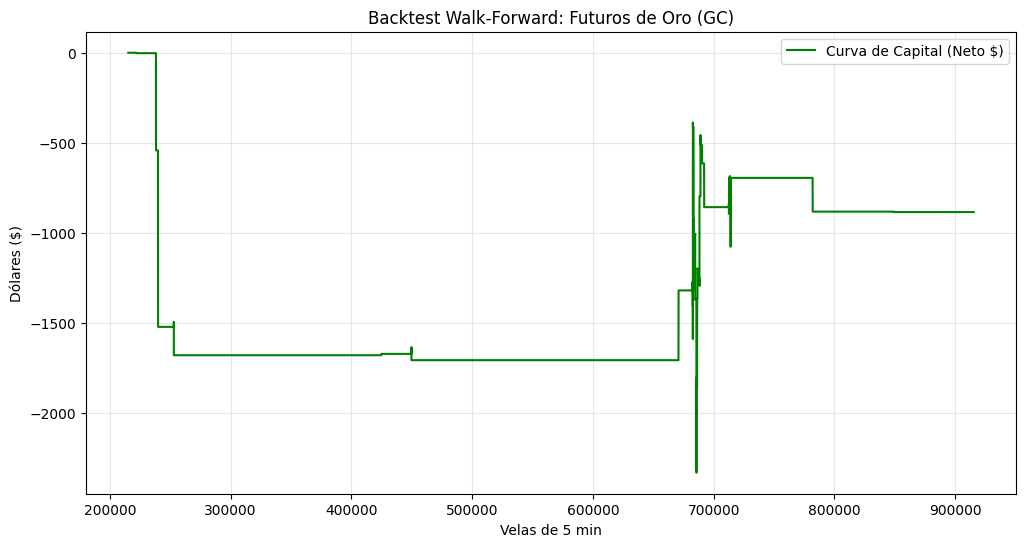

Total Trades: 114
Win Rate: 49.12%
Ganancia Media por Trade: $-7.76


In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(backtest_df['equity_curve'], label='Curva de Capital (Neto $)', color='green')
plt.title('Backtest Walk-Forward: Futuros de Oro (GC)')
plt.ylabel('Dólares ($)')
plt.xlabel('Velas de 5 min')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Métricas rápidas
n_trades = trades_mask.sum()
win_rate = len(backtest_df[backtest_df['pnl_net'] > 0]) / n_trades if n_trades > 0 else 0
avg_trade = backtest_df.loc[trades_mask, 'pnl_net'].mean()

print(f"Total Trades: {n_trades}")
print(f"Win Rate: {win_rate:.2%}")
print(f"Ganancia Media por Trade: ${avg_trade:.2f}")


In [85]:
# ¿Cuánto perdemos por culpa de los costes?
pnl_bruto = backtest_df.loc[trades_mask, 'pnl_gross'].sum()
pnl_neto = backtest_df.loc[trades_mask, 'pnl_net'].sum()

print(f"PnL Bruto: ${pnl_bruto:,.2f}")
print(f"PnL Neto: ${pnl_neto:,.2f}")
print(f"Costes Totales: ${pnl_bruto - pnl_neto:,.2f}")

# ¿El modelo tiene sesgo?
print("\nDistribución de predicciones con confianza:")
print(backtest_df[trades_mask]['pred'].value_counts())


PnL Bruto: $2,360.00
PnL Neto: $-14,897.50
Costes Totales: $17,257.50

Distribución de predicciones con confianza:
pred
2    681
0     86
Name: count, dtype: int64


In [88]:
from sklearn.utils.class_weight import compute_class_weight

# Diccionario para guardar qué features fueron importantes en cada ventana
feature_importance_history = []

for start in range(0, len(X) - train_size - test_size, step):
    end_train = start + train_size
    end_test = end_train + test_size
    
    print(f"\n--- Entrenando Ventana: {start} a {end_train} ---")
    
    X_train_wf, y_train_wf = X[start:end_train], y[start:end_train]
    X_test_wf, y_test_wf = X[end_train:end_test], y[end_train:end_test]
    
    # --- 1. EXPLICABILIDAD (BALANCEO DE CLASES) ---
    # Calculamos pesos para que el modelo no ignore las ventas (0)
    unique_classes = np.unique(y_train_wf)
    weights = compute_class_weight(class_weight='balanced', classes=unique_classes, y=y_train_wf)
    class_weight_dict = {cls: weight for cls, weight in zip(unique_classes, weights)}
    
    # 2. Construcción y Entrenamiento con pesos
    model = build_lstm_model((14, 18))
    model.fit(X_train_wf, y_train_wf, 
              epochs=10, 
              batch_size=256, 
              class_weight=class_weight_dict, # <--- QUITAMOS EL SESGO AQUÍ
              verbose=0) 
    
    # 3. Predicciones
    preds = model.predict(X_test_wf)
    pred_classes = np.argmax(preds, axis=1)
    
    # --- 4. EXPLICABILIDAD (PERMUTATION IMPORTANCE) ---
    # Vamos a ver qué features están moviendo el modelo en esta ventana
    baseline_acc = np.mean(pred_classes == y_test_wf)
    importances = []
    
    # Solo probamos con una muestra del test para que no tarde horas
    sample_idx = np.random.choice(len(X_test_wf), 5000, replace=False)
    X_sample = X_test_wf[sample_idx].copy()
    
    for f_idx in range(len(feature_cols)):
        save_col = X_sample[:, :, f_idx].copy()
        # Desordenamos solo una feature
        np.random.shuffle(X_sample[:, :, f_idx])
        
        # Medimos cuánto cae el acierto
        shuff_preds = np.argmax(model.predict(X_sample, verbose=0), axis=1)
        acc_drop = baseline_acc - np.mean(shuff_preds == y_test_wf[sample_idx])
        importances.append(acc_drop)
        
        # Restauramos la columna
        X_sample[:, :, f_idx] = save_col
        
    feature_importance_history.append(importances)
    
    # 5. Guardar resultados (como ya tenías)
    window_results = pd.DataFrame({
        'actual': y_test_wf,
        'pred': pred_classes,
        'prob_buy': preds[:, 2],
        'prob_sell': preds[:, 0]
    })
    all_predictions.append(window_results)

# Al final, puedes ver qué features dominaron el Walk-Forward
avg_importance = np.mean(feature_importance_history, axis=0)
importance_df = pd.DataFrame({'feature': feature_cols, 'importance': avg_importance}).sort_values(by='importance', ascending=False)
print("\nTop Features Predictivas:")
print(importance_df.head(10))



--- Entrenando Ventana: 0 a 200000 ---


c:\Users\LIJUN\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step

--- Entrenando Ventana: 50000 a 250000 ---


c:\Users\LIJUN\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step

--- Entrenando Ventana: 100000 a 300000 ---


...

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step

--- Entrenando Ventana: 600000 a 800000 ---


c:\Users\LIJUN\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step

--- Entrenando Ventana: 650000 a 850000 ---


c:\Users\LIJUN\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step

Top Features Predictivas:
                feature  importance
8           range_ticks    0.015254
11  dist_high_cum_ticks    0.004097
12   dist_low_cum_ticks    0.001983
3              hour_cos    0.001854
1               min_cos    0.001669
10     lower_wick_ticks    0.001640
9      upper_wick_ticks    0.001297
6      is_high_vol_hour    0.001040
14              vol_eff    0.000983
17              log_ret    0.000340


C:\Users\LIJUN\AppData\Local\Temp\ipykernel_23376\1529607029.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')


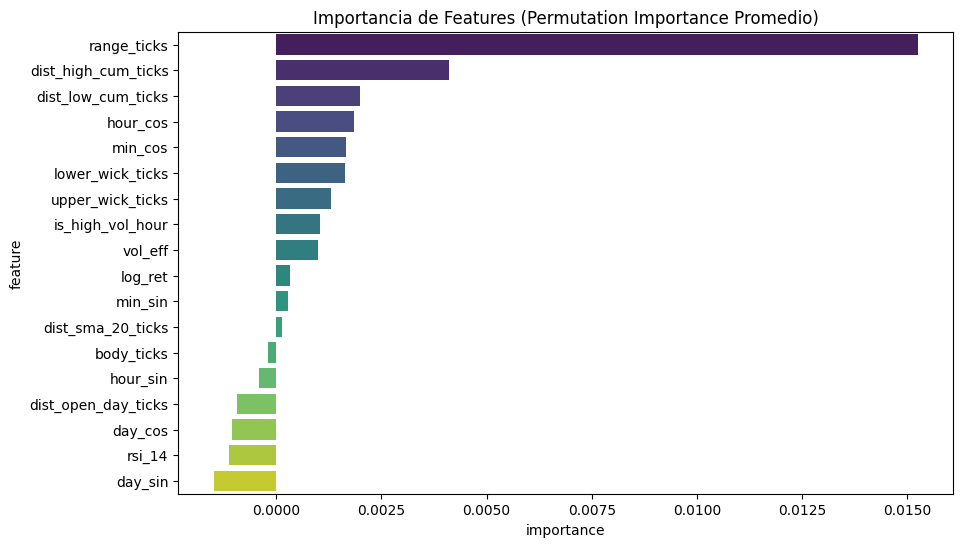

In [89]:
# Mostrar el ranking de lo que realmente importa para el modelo
import seaborn as sns
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({'feature': feature_cols, 'importance': np.mean(feature_importance_history, axis=0)})
importance_df = importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')
plt.title('Importancia de Features (Permutation Importance Promedio)')
plt.show()


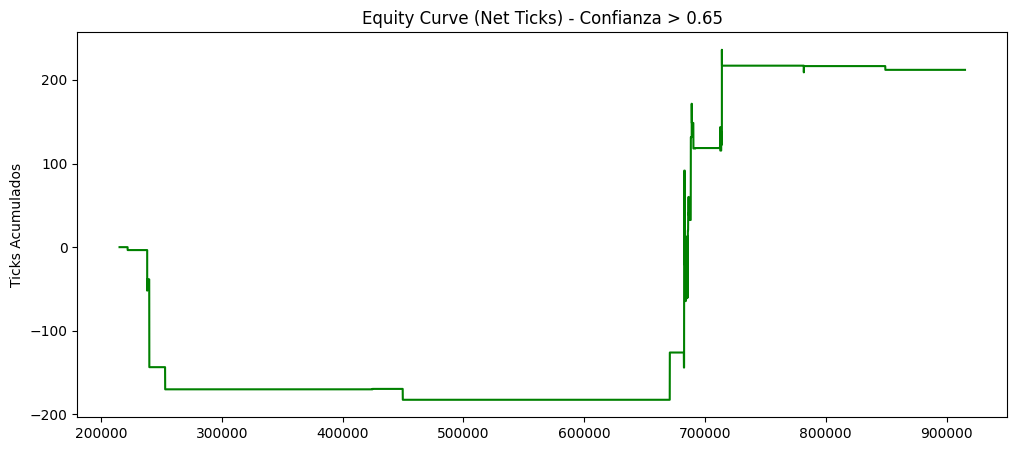

Total Trades: 114
Ratio Compras/Ventas: 112 / 2


In [91]:
# Unimos los resultados del Walk-Forward con los precios
backtest_df = df_features.iloc[-len(final_backtest):].copy()
backtest_df['pred'] = final_backtest['pred'].values
backtest_df['prob_buy'] = final_backtest['prob_buy'].values
backtest_df['prob_sell'] = final_backtest['prob_sell'].values

# Filtro de confianza (puedes jugar con este valor: 0.55, 0.60, 0.70)
CONFIDENCIA = 0.65
TICK_SIZE = spec['tick_size']

# Calculamos PnL en Ticks (Cierre a 6 velas = 30 min)
backtest_df['trade_ret'] = 0.0
# Compras
mask_buy = (backtest_df['pred'] == 2) & (backtest_df['prob_buy'] > CONFIDENCIA)
backtest_df.loc[mask_buy, 'trade_ret'] = (backtest_df['close'].shift(-6) - backtest_df['close']) / TICK_SIZE
# Ventas
mask_sell = (backtest_df['pred'] == 0) & (backtest_df['prob_sell'] > CONFIDENCIA)
backtest_df.loc[mask_sell, 'trade_ret'] = (backtest_df['close'] - backtest_df['close'].shift(-6)) / TICK_SIZE

# Aplicamos costos (Comisión + Spread + Slippage) aprox 2.5 ticks
COSTS = 2.5
backtest_df['pnl_net_ticks'] = 0.0
trades = mask_buy | mask_sell
backtest_df.loc[trades, 'pnl_net_ticks'] = backtest_df['trade_ret'] - COSTS

# Graficamos la curva de capital en Ticks
plt.figure(figsize=(12, 5))
backtest_df['pnl_net_ticks'].cumsum().plot(color='green')
plt.title(f'Equity Curve (Net Ticks) - Confianza > {CONFIDENCIA}')
plt.ylabel('Ticks Acumulados')
plt.show()

print(f"Total Trades: {trades.sum()}")
print(f"Ratio Compras/Ventas: {mask_buy.sum()} / {mask_sell.sum()}")


In [92]:
# Lista optimizada basada en tu ranking de importancia
feature_cols_clean = [
    # 1. Los pesos pesados (Volatilidad y Geometría)
    'range_ticks', 
    'body_ticks', 
    'upper_wick_ticks', 
    'lower_wick_ticks',
    
    # 2. Contexto de Niveles (Los que sí funcionan)
    'dist_high_cum_ticks', 
    'dist_low_cum_ticks',
    'dist_sma_20_ticks',
    
    # 3. Esfuerzo y Retorno
    'vol_eff', 
    'log_ret',
    
    # 4. Tiempo (Solo los componentes que no dieron negativo)
    'hour_cos', 
    'min_sin', 
    'min_cos'
]

print(f"Entrenando con {len(feature_cols_clean)} features de alta calidad.")


Entrenando con 12 features de alta calidad.


In [93]:
# Re-escalamos solo con las features buenas
scaler = StandardScaler()
df_model_clean = df_features.dropna(subset=feature_cols_clean + [target_col]).copy()
df_model_clean[feature_cols_clean] = scaler.fit_transform(df_model_clean[feature_cols_clean])

# Creamos el nuevo X (ahora tendrá 12 o 13 columnas en lugar de 18)
X_clean, y_clean = create_lstm_dataset(df_model_clean, feature_cols_clean, target_col, lookback=14)

print(f"Nuevo X shape: {X_clean.shape}")


Nuevo X shape: (915268, 14, 12)


In [94]:
all_predictions_clean = []

# Ajustamos el input_shape del modelo a la nueva cantidad de features
input_dim = len(feature_cols_clean)

for start in range(0, len(X_clean) - train_size - test_size, step):
    end_train = start + train_size
    end_test = end_train + test_size
    
    X_train_wf, y_train_wf = X_clean[start:end_train], y_clean[start:end_train]
    X_test_wf, y_test_wf = X_clean[end_train:end_test], y_clean[end_train:end_test]
    
    # Pesos de clase: Obligamos al modelo a que le importe el triple no fallar un SHORT
    unique_classes = np.unique(y_train_wf)
    weights = compute_class_weight('balanced', classes=unique_classes, y=y_train_wf)
    class_weight_dict = {cls: weight for cls, weight in zip(unique_classes, weights)}
    
    # Construcción del modelo con la nueva dimensión
    model = build_lstm_model((14, input_dim))
    
    # Entrenamos un poco más (15 epochs) para que asimile mejor las features limpias
    model.fit(X_train_wf, y_train_wf, 
              epochs=15, 
              batch_size=512, 
              class_weight=class_weight_dict, 
              verbose=0) 
    
    preds = model.predict(X_test_wf)
    pred_classes = np.argmax(preds, axis=1)
    
    all_predictions_clean.append(pd.DataFrame({
        'actual': y_test_wf,
        'pred': pred_classes,
        'prob_buy': preds[:, 2],
        'prob_sell': preds[:, 0]
    }))

final_backtest_clean = pd.concat(all_predictions_clean)


c:\Users\LIJUN\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


c:\Users\LIJUN\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


c:\Users\LIJUN\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step


c:\Users\LIJUN\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step


c:\Users\LIJUN\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step


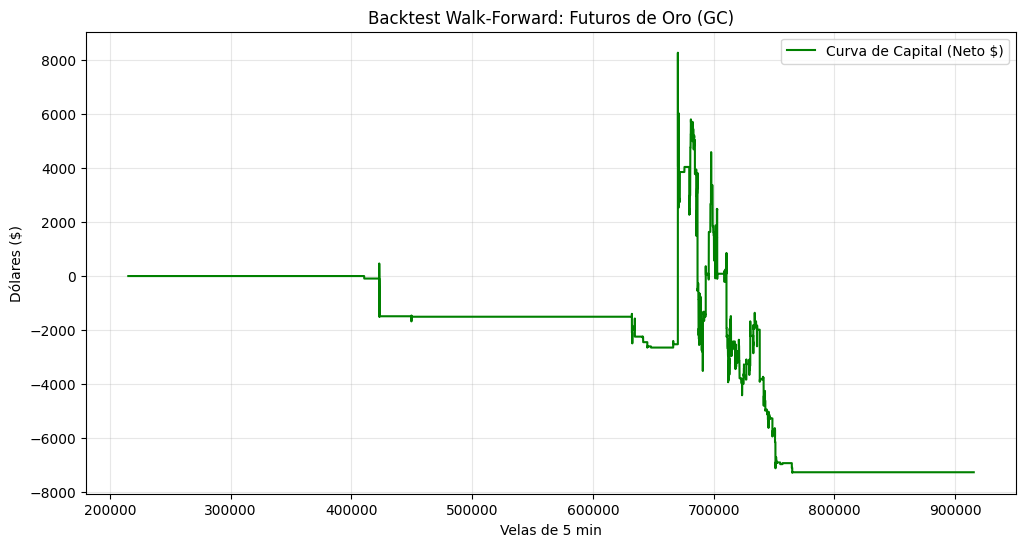

Total Trades: 1148
Win Rate: 45.12%
Ganancia Media por Trade: $-6.33


In [101]:
# 1. Unir predicciones con precios reales
# Importante: Las predicciones empiezan después del primer 'train_size' del Walk-Forward
backtest_df = df_model.iloc[-len(final_backtest_clean):].copy()
backtest_df['pred'] = final_backtest_clean['pred'].values
backtest_df['prob_buy'] = final_backtest_clean['prob_buy'].values
backtest_df['prob_sell'] = final_backtest_clean['prob_sell'].values

# 2. Definir parámetros de ejecución (basados en tu spec de GC)
TICK_SIZE = spec['tick_size']    # 0.1
TICK_VALUE = spec['tick_value']  # $10.0
COMMISSION = 2.5                 # $2.5 por trade (ajusta según tu broker)
SPREAD_COST = 1.0                # 1 tick de spread medio
SLIPPAGE = 1.0                   # 1 tick de error de ejecución

COST_PER_TRADE = (COMMISSION) + (SPREAD_COST + SLIPPAGE) * TICK_VALUE # Total en $
# 3. Calcular el retorno de la operación (en ticks)
# Si compramos (pred=2), ganamos la diferencia a 3 velas vista
backtest_df['trade_ret_ticks'] = 0.0
# NUEVO FILTRO AGRESIVO
CONFIDENCIA_PRO = 0.82  # Sube el listón mucho más
TARGET_HORIZON = 12     # Vamos a ver qué pasó a 60 minutos (si tienes los datos)

# Caso Long (2)
mask_long = (backtest_df['pred'] == 2) & (backtest_df['prob_buy'] > CONFIDENCIA_PRO)
# Caso Short (0)
mask_short = (backtest_df['pred'] == 0) & (backtest_df['prob_sell'] > CONFIDENCIA_PRO)

# ... (resto del cálculo de PnL) ...

# Caso Long (2)
mask_long = (backtest_df['pred'] == 2) & (backtest_df['prob_buy'] > 0.7) # Filtro de confianza
backtest_df.loc[mask_long, 'trade_ret_ticks'] = (backtest_df['close'].shift(-3) - backtest_df['close']) / TICK_SIZE

# Caso Short (0)
mask_short = (backtest_df['pred'] == 0) & (backtest_df['prob_sell'] > 0.7)
backtest_df.loc[mask_short, 'trade_ret_ticks'] = (backtest_df['close'] - backtest_df['close'].shift(-3)) / TICK_SIZE

# 4. Convertir a Dinero Neto
backtest_df['pnl_gross'] = backtest_df['trade_ret_ticks'] * TICK_VALUE
backtest_df['pnl_net'] = 0.0
# Solo restamos costes si hubo operación (pred 0 o 2 con confianza)
trades_mask = (mask_long | mask_short)
backtest_df.loc[trades_mask, 'pnl_net'] = backtest_df['pnl_gross'] - COST_PER_TRADE

# 5. Curva de Capital
backtest_df['equity_curve'] = backtest_df['pnl_net'].cumsum()


plt.figure(figsize=(12, 6))
plt.plot(backtest_df['equity_curve'], label='Curva de Capital (Neto $)', color='green')
plt.title('Backtest Walk-Forward: Futuros de Oro (GC)')
plt.ylabel('Dólares ($)')
plt.xlabel('Velas de 5 min')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Métricas rápidas
n_trades = trades_mask.sum()
win_rate = len(backtest_df[backtest_df['pnl_net'] > 0]) / n_trades if n_trades > 0 else 0
avg_trade = backtest_df.loc[trades_mask, 'pnl_net'].mean()

print(f"Total Trades: {n_trades}")
print(f"Win Rate: {win_rate:.2%}")
print(f"Ganancia Media por Trade: ${avg_trade:.2f}")


In [102]:
# ¿Cuánto perdemos por culpa de los costes?
pnl_bruto = backtest_df.loc[trades_mask, 'pnl_gross'].sum()
pnl_neto = backtest_df.loc[trades_mask, 'pnl_net'].sum()

print(f"PnL Bruto: ${pnl_bruto:,.2f}")
print(f"PnL Neto: ${pnl_neto:,.2f}")
print(f"Costes Totales: ${pnl_bruto - pnl_neto:,.2f}")

# ¿El modelo tiene sesgo?
print("\nDistribución de predicciones con confianza:")
print(backtest_df[trades_mask]['pred'].value_counts())


PnL Bruto: $18,560.00
PnL Neto: $-7,270.00
Costes Totales: $25,830.00

Distribución de predicciones con confianza:
pred
2    1147
0       1
Name: count, dtype: int64


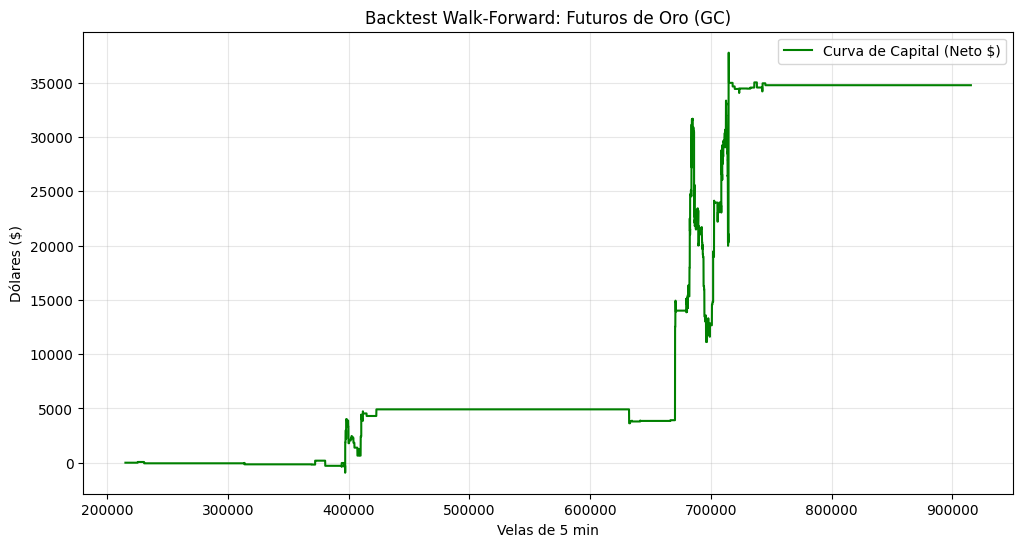

Total Trades: 682
Win Rate: 49.85%
Ganancia Media por Trade: $50.98


In [119]:
# 1. Unir predicciones con precios reales
# Importante: Las predicciones empiezan después del primer 'train_size' del Walk-Forward
backtest_df = df_model.iloc[-len(final_backtest_clean):].copy()
backtest_df['pred'] = final_backtest_clean['pred'].values
backtest_df['prob_buy'] = final_backtest_clean['prob_buy'].values
backtest_df['prob_sell'] = final_backtest_clean['prob_sell'].values
# --- AJUSTE DINÁMICO ---
TARGET_HORIZON = 12 # 60 minutos (coherente con lo que buscamos)
CONFIDENCIA_PRO = 0.75 # Un punto medio entre 0.65 y 0.82

# 1. Filtro de Volatilidad (ATR o similar)
# Solo operamos si el rango de los últimos ticks es suficiente para cubrir costes
# Usamos un umbral: el movimiento promedio debe ser > 5 ticks para que valga la pena
min_volatility_threshold = 5.0 

# 2. Sincronizar el retorno con el horizonte real
backtest_df['trade_ret_ticks'] = 0.0
# Mantenemos el listón alto para compras, pero lo bajamos para ventas
CONF_BUY = 0.78  
CONF_SELL = 0.62 # <--- Bajamos drásticamente el umbral para las ventas

mask_long = (backtest_df['pred'] == 2) & (backtest_df['prob_buy'] > CONF_BUY)
mask_short = (backtest_df['pred'] == 0) & (backtest_df['prob_sell'] > CONF_SELL)

# Importante: Usa el horizonte largo que definimos (60 min)
TARGET_HORIZON = 12 


# Bajamos el listón un poco más para las ventas para compensar el sesgo
# mask_long = (backtest_df['pred'] == 2) & (backtest_df['prob_buy'] > 0.78)
# mask_short = (backtest_df['pred'] == 0) & (backtest_df['prob_sell'] > 0.74) 

# Caso Long (2) con filtro de volatilidad
# mask_long = (backtest_df['pred'] == 2) & \
#             (backtest_df['prob_buy'] > CONFIDENCIA_PRO) & \
#             (backtest_df['range_ticks'] > min_volatility_threshold)

backtest_df.loc[mask_long, 'trade_ret_ticks'] = (backtest_df['close'].shift(-TARGET_HORIZON) - backtest_df['close']) / TICK_SIZE

# Caso Short (0)
# mask_short = (backtest_df['pred'] == 0) & \
#              (backtest_df['prob_sell'] > CONFIDENCIA_PRO) & \
#              (backtest_df['range_ticks'] > min_volatility_threshold)

backtest_df.loc[mask_short, 'trade_ret_ticks'] = (backtest_df['close'] - backtest_df['close'].shift(-TARGET_HORIZON)) / TICK_SIZE

# ... (El resto del cálculo de PnL neto se mantiene igual)
# 4. Convertir a Dinero Neto
backtest_df['pnl_gross'] = backtest_df['trade_ret_ticks'] * TICK_VALUE
backtest_df['pnl_net'] = 0.0
# Solo restamos costes si hubo operación (pred 0 o 2 con confianza)
trades_mask = (mask_long | mask_short)
backtest_df.loc[trades_mask, 'pnl_net'] = backtest_df['pnl_gross'] - COST_PER_TRADE

# 5. Curva de Capital
backtest_df['equity_curve'] = backtest_df['pnl_net'].cumsum()


plt.figure(figsize=(12, 6))
plt.plot(backtest_df['equity_curve'], label='Curva de Capital (Neto $)', color='green')
plt.title('Backtest Walk-Forward: Futuros de Oro (GC)')
plt.ylabel('Dólares ($)')
plt.xlabel('Velas de 5 min')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Métricas rápidas
n_trades = trades_mask.sum()
win_rate = len(backtest_df[backtest_df['pnl_net'] > 0]) / n_trades if n_trades > 0 else 0
avg_trade = backtest_df.loc[trades_mask, 'pnl_net'].mean()

print(f"Total Trades: {n_trades}")
print(f"Win Rate: {win_rate:.2%}")
print(f"Ganancia Media por Trade: ${avg_trade:.2f}")

In [120]:
# ¿Cuánto perdemos por culpa de los costes?
pnl_bruto = backtest_df.loc[trades_mask, 'pnl_gross'].sum()
pnl_neto = backtest_df.loc[trades_mask, 'pnl_net'].sum()

print(f"PnL Bruto: ${pnl_bruto:,.2f}")
print(f"PnL Neto: ${pnl_neto:,.2f}")
print(f"Costes Totales: ${pnl_bruto - pnl_neto:,.2f}")

# ¿El modelo tiene sesgo?
print("\nDistribución de predicciones con confianza:")
print(backtest_df[trades_mask]['pred'].value_counts())


PnL Bruto: $50,110.00
PnL Neto: $34,765.00
Costes Totales: $15,345.00

Distribución de predicciones con confianza:
pred
0    595
2     87
Name: count, dtype: int64


In [121]:
def run_pro_backtest(df_results, df_ohlcv, spec, conf_buy=0.78, conf_sell=0.62, horizon=12, sl_ticks=10, tp_ticks=40):
    """
    Backtest con salida por tiempo, Stop Loss y Take Profit.
    Verifica vela a vela lo que ocurre dentro del horizonte.
    """
    # 1. Alineación de datos
    # Asegúrate de que df_ohlcv tenga el mismo índice que df_results
    df = df_ohlcv.iloc[-len(df_results):].copy()
    df['pred'] = df_results['pred'].values
    df['prob_buy'] = df_results['prob_buy'].values
    df['prob_sell'] = df_results['prob_sell'].values
    
    tick_size = spec['tick_size']
    tick_value = spec['tick_value']
    # Costos fijos (Comisión + 1 tick spread + 1 tick slippage)
    cost_per_trade = 2.5 + (2.0 * tick_value) 
    
    # 2. Inicialización de resultados
    pnl_net_list = []
    trade_durations = []
    exit_types = [] # 'Time', 'SL', 'TP'

    # 3. Simulación Vela a Vela (Solo para los trades disparados)
    # Filtramos las señales primero para ganar velocidad
    trades_idx = df[( (df['pred'] == 2) & (df['prob_buy'] > conf_buy) ) | 
                    ( (df['pred'] == 0) & (df['prob_sell'] > conf_sell) )].index

    # Pre-calculamos los valores de SL y TP en precio
    sl_price = sl_ticks * tick_size
    tp_price = tp_ticks * tick_size

    for idx in trades_idx:
        row = df.loc[idx]
        entry_price = row['close']
        is_long = row['pred'] == 2
        
        # Miramos las próximas 'horizon' velas
        future_segment = df_ohlcv.loc[idx + 1 : idx + horizon]
        
        executed_pnl = None
        
        for i, (f_idx, f_row) in enumerate(future_segment.iterrows()):
            if is_long:
                # ¿Tocó SL?
                if f_row['low'] <= entry_price - sl_price:
                    executed_pnl = -sl_ticks * tick_value
                    exit_types.append('SL')
                    break
                # ¿Tocó TP?
                elif f_row['high'] >= entry_price + tp_price:
                    executed_pnl = tp_ticks * tick_value
                    exit_types.append('TP')
                    break
            else: # Short
                # ¿Tocó SL?
                if f_row['high'] >= entry_price + sl_price:
                    executed_pnl = -sl_ticks * tick_value
                    exit_types.append('SL')
                    break
                # ¿Tocó TP?
                elif f_row['low'] <= entry_price - tp_price:
                    executed_pnl = tp_ticks * tick_value
                    exit_types.append('TP')
                    break
        
        # Si no tocó SL ni TP en el horizonte, cerramos por tiempo
        if executed_pnl is None:
            final_price = future_segment['close'].iloc[-1] if not future_segment.empty else entry_price
            pnl_ticks = (final_price - entry_price) / tick_size if is_long else (entry_price - final_price) / tick_size
            executed_pnl = pnl_ticks * tick_value
            exit_types.append('Time')
            trade_durations.append(len(future_segment))
        else:
            trade_durations.append(i + 1)

        pnl_net_list.append(executed_pnl - cost_per_trade)

    # 4. Estadísticas finales
    pnl_net_list = np.array(pnl_net_list)
    equity_curve = np.cumsum(pnl_net_list)
    
    print(f"--- RESULTADOS FINALES CON SL={sl_ticks} / TP={tp_ticks} ---")
    print(f"Total Trades: {len(pnl_net_list)}")
    print(f"Win Rate: {(pnl_net_list > 0).mean():.2%}")
    print(f"Net Profit: ${equity_curve[-1]:,.2f}")
    print(f"Salidas: {pd.Series(exit_types).value_counts().to_dict()}")
    
    plt.figure(figsize=(12,6))
    plt.plot(equity_curve, color='green', linewidth=2)
    plt.title('Equity Curve Profesional (SL/TP)')
    plt.grid(True, alpha=0.3)
    plt.show()

    return pnl_net_list

# EJECUCIÓN



--- RESULTADOS FINALES CON SL=20 / TP=40 ---
Total Trades: 417
Win Rate: 39.33%
Net Profit: $-10,692.50
Salidas: {'SL': 194, 'Time': 155, 'TP': 68}


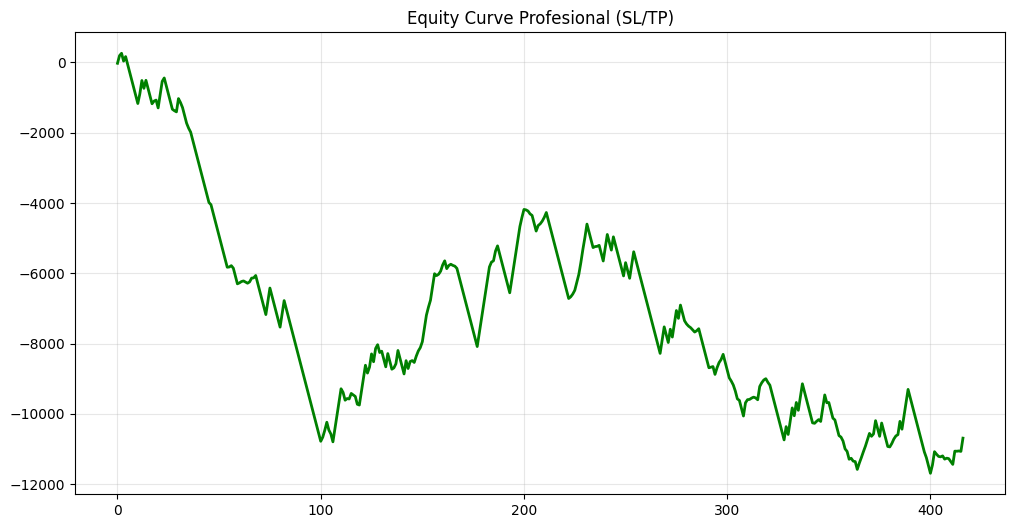

In [126]:
# PRUEBA ESTA CONFIGURACIÓN
pnl_neto_final = run_pro_backtest(
    final_backtest_clean, 
    df_features, # Asegúrate de que este sea el DF con OHLCV original
    spec, 
    conf_buy=0.75,     # Bajamos un poco para tener más trades (estadística)
    conf_sell=0.65,    # Mantenemos el sesgo a favor de ventas que funcionó
    horizon=12,        # 60 minutos
    sl_ticks=20,       # <--- DALE AIRE (2.00$ de margen)
    tp_ticks=40        # <--- BUSCA UN RATIO 1:2
)


In [128]:
df_features.iloc[0]

datetime               2010-09-20 08:35:00
open                                1282.8
high                                1282.8
low                                 1281.9
close                               1282.0
volume                                 108
openint                                0.0
ticker                                  GC
per                                   5min
trading_date                    2010-09-20
open_day                            1279.8
high_cum                            1283.4
low_cum                             1279.8
volume_cum                            2405
future_ticks                           5.0
target                                   2
min_sin                           0.779884
min_cos                          -0.625923
hour_sin                          0.866025
hour_cos                              -0.5
day_sin                                0.0
day_cos                                1.0
is_high_vol_hour                         0
body_ticks 

In [ ]:
import mplfinance as mpf

def run_hybrid_backtest(df_signals, df_1min, spec, conf_buy=0.78, conf_sell=0.62, horizon_m=60, sl_ticks=18, tp_ticks=35):
    tick_size = spec['tick_size']
    tick_value = spec['tick_value']
    cost_per_trade = 2.5 + (2.0 * tick_value)
    
    # --- FILTRO DE TENDENCIA (SMA 200) ---
    # Solo permitimos comprar si el precio > SMA200
    # Solo permitimos vender si el precio < SMA200
    # (Asegúrate de que 'sma_200' esté en tu df_signals)
    
    # --- DENTRO DE run_hybrid_backtest ---
    # Definimos una "Zona de Valor"
    # No vendemos si el precio está X ticks por debajo de la SMA20 (está muy estirado)
    # No operamos si el mercado no tiene fuerza (ADX bajo) 
    # o si el rango de las últimas 14 velas es muy pequeño.
    
    df_signals['range_14'] = (df_signals['high'].rolling(14).max() - df_signals['low'].rolling(14).min()) / spec['tick_size']

    # Umbral: Solo operamos si el rango de la última hora es > 15-20 ticks
    MIN_RANGE_TICKS = 20 

    mask_sell_valid = (df_signals['prob_sell'] > conf_sell) & \
                      (df_signals['range_14'] > MIN_RANGE_TICKS) # <-- EVITA RANGOS LATERALES

    MAX_DIST_TICKS = 15 

    df_signals['dist_sma'] = (df_signals['sma_20'] - df_signals['close']) / spec['tick_size']

    # mask_sell_valid = (df_signals['prob_sell'] > conf_sell) & \
    #                   (df_signals['close'] < df_signals['sma_20']) & \
    #                   (df_signals['dist_sma'] < MAX_DIST_TICKS) # <-- EVITA VENDER EN EL SUELO

    # Definimos los filtros de tendencia usando la SMA de 20 que ya tienes en las features
    mask_buy_valid = (df_signals['prob_buy'] > conf_buy) & \
                     (df_signals['close'] > df_signals['sma_20'])
    
    # mask_sell_valid = (df_signals['prob_sell'] > conf_sell) & \
    #                   (df_signals['close'] < df_signals['sma_20'])
    
    # 1. Filtramos las señales que van A FAVOR de la tendencia
    trades = df_signals[mask_buy_valid | mask_sell_valid].copy()
    
    print(f"Trades que pasan el filtro de tendencia: {len(trades)}")

    
    results = []
    df_1min_idx = df_1min.set_index('datetime').sort_index()

    print(f"Trades filtrados por tendencia: {len(trades)}")

    for idx, row in trades.iterrows():
        entry_time = row['datetime']
        entry_price = row['close']
        is_long = row['pred'] == 2
        
        # Precios de salida
        sl_price = entry_price - (sl_ticks * tick_size) if is_long else entry_price + (sl_ticks * tick_size)
        tp_price = entry_price + (tp_ticks * tick_size) if is_long else entry_price - (tp_ticks * tick_size)
        
        # 2. Buscar ventana de 1 min para ejecución (60 velas de 1 min)
        # Empezamos 1 minuto después de la señal
        future_1min = df_1min_idx.loc[entry_time + pd.Timedelta(minutes=1) : 
                                      entry_time + pd.Timedelta(minutes=horizon_m)]
        
        pnl_ticks = None
        exit_time = entry_time + pd.Timedelta(minutes=horizon_m)
        exit_type = 'Time'

        for t_1min, row_1min in future_1min.iterrows():
            if is_long:
                if row_1min['low'] <= sl_price:
                    pnl_ticks = -sl_ticks
                    exit_type, exit_time = 'SL', t_1min
                    break
                elif row_1min['high'] >= tp_price:
                    pnl_ticks = tp_ticks
                    exit_type, exit_time = 'TP', t_1min
                    break
            else: # Short
                if row_1min['high'] >= sl_price:
                    pnl_ticks = -sl_ticks
                    exit_type, exit_time = 'SL', t_1min
                    break
                elif row_1min['low'] <= tp_price:
                    pnl_ticks = tp_ticks
                    exit_type, exit_time = 'TP', t_1min
                    break
        
        # Si no tocó nada en 60 mins, cerramos al precio de cierre de la última vela de 1 min
        if pnl_ticks is None:
            final_price = future_1min['close'].iloc[-1] if not future_1min.empty else entry_price
            pnl_ticks = (final_price - entry_price) / tick_size if is_long else (entry_price - final_price) / tick_size

        results.append({
            'entry_time': entry_time,
            'exit_time': exit_time,
            'type': 'Long' if is_long else 'Short',
            'exit_reason': exit_type,
            'pnl_usd': (pnl_ticks * tick_value) - cost_per_trade,
            'pnl_ticks': pnl_ticks
        })

    return pd.DataFrame(results)

# EJECUCIÓN
# Nota: df_signals debe ser tu df_gold con las predicciones unidas


In [ ]:
df_results = run_hybrid_backtest(backtest_df, df_min, spec, sl_ticks=35, tp_ticks=60)


Trades que pasan el filtro de tendencia: 602
Trades filtrados por tendencia: 602


In [149]:
def run_hybrid_backtest_v2(df_signals, df_1min, spec, conf_buy=0.78, conf_sell=0.62, horizon_m=60, sl_ticks=35, tp_ticks=60):
    """
    Backtest Híbrido Profesional:
    - Señales en 5 min.
    - Ejecución y SL/TP en 1 min.
    - Filtros de Tendencia, Volatilidad y Zona de Valor.
    """
    # Configuración de Activo
    tick_size = spec['tick_size']
    tick_value = spec['tick_value']
    cost_per_trade = 2.5 + (2.0 * tick_value) # Comisión + 2 ticks (spread/slip)
    
    # --- 1. PRE-CÁLCULO DE FILTROS ---
    # Rango de la última hora (evita mercados laterales/muertos)
    df_signals['range_14'] = (df_signals['high'].rolling(14).max() - df_signals['low'].rolling(14).min()) / tick_size
    # Distancia a la media (evita entrar cuando el precio está estirado/sobrevendido)
    df_signals['dist_sma'] = (df_signals['sma_20'] - df_signals['close']).abs() / tick_size
    
    # --- 2. FILTRADO DE SEÑALES ---
    # Filtro LONG: Tendencia alcista + No muy lejos de la media + Rango mínimo
    mask_buy_valid = (df_signals['prob_buy'] > conf_buy) & \
                     (df_signals['close'] > df_signals['sma_20']) & \
                     (df_signals['dist_sma'] < 15) & \
                     (df_signals['range_14'] > 20)
    
    # Filtro SHORT: Tendencia bajista + No muy lejos de la media + Rango mínimo
    mask_sell_valid = (df_signals['prob_sell'] > conf_sell) & \
                      (df_signals['close'] < df_signals['sma_20']) & \
                      (df_signals['dist_sma'] < 15) & \
                      (df_signals['range_14'] > 20)
    
    trades = df_signals[mask_buy_valid | mask_sell_valid].copy()
    print(f"Total señales filtradas: {len(trades)}")

    # Preparar índice de 1 min para búsqueda rápida
    df_1min_idx = df_1min.set_index('datetime').sort_index()
    results = []

    # --- 3. BUCLE DE EJECUCIÓN ---
    for idx, row in trades.iterrows():
        entry_time = row['datetime']
        entry_price = row['close']
        is_long = row['pred'] == 2
        
        # Niveles de Salida
        sl_price = entry_price - (sl_ticks * tick_size) if is_long else entry_price + (sl_ticks * tick_size)
        tp_price = entry_price + (tp_ticks * tick_size) if is_long else entry_price - (tp_ticks * tick_size)
        
        # Ventana de 1 minuto para barrido de SL/TP
        future_1min = df_1min_idx.loc[entry_time + pd.Timedelta(minutes=1) : 
                                      entry_time + pd.Timedelta(minutes=horizon_m)]
        
        pnl_ticks = None
        exit_time = entry_time + pd.Timedelta(minutes=horizon_m)
        exit_type = 'Time'

        for t_1min, row_1min in future_1min.iterrows():
            if is_long:
                if row_1min['low'] <= sl_price:
                    pnl_ticks = -sl_ticks
                    exit_type, exit_time = 'SL', t_1min
                    break
                elif row_1min['high'] >= tp_price:
                    pnl_ticks = tp_ticks
                    exit_type, exit_time = 'TP', t_1min
                    break
            else: # Short
                if row_1min['high'] >= sl_price:
                    pnl_ticks = -sl_ticks
                    exit_type, exit_time = 'SL', t_1min
                    break
                elif row_1min['low'] <= tp_price:
                    pnl_ticks = tp_ticks
                    exit_type, exit_time = 'TP', t_1min
                    break
        
        # Cierre por tiempo si no saltó SL/TP
        if pnl_ticks is None:
            final_price = future_1min['close'].iloc[-1] if not future_1min.empty else entry_price
            pnl_ticks = (final_price - entry_price) / tick_size if is_long else (entry_price - final_price) / tick_size

        results.append({
            'entry_time': entry_time,
            'exit_time': exit_time,
            'type': 'Long' if is_long else 'Short',
            'exit_reason': exit_type,
            'pnl_usd': (pnl_ticks * tick_value) - cost_per_trade,
            'pnl_ticks': pnl_ticks
        })

    results_df = pd.DataFrame(results)
    
    # 4. MÉTRICAS FINALES
    if not results_df.empty:
        results_df['equity'] = results_df['pnl_usd'].cumsum()
        print(f"PnL Final: ${results_df['equity'].iloc[-1]:,.2f}")
        print(f"Win Rate: {(results_df['pnl_ticks'] > 0).mean():.2%}")
        
    return results_df


In [150]:
df_results = run_hybrid_backtest_v2(backtest_df, df_min, spec, sl_ticks=35, tp_ticks=60)

Total señales filtradas: 160
PnL Final: $-1,300.00
Win Rate: 45.00%


In [169]:
def run_hybrid_backtest_v3(df_signals, df_1min, spec, conf_buy=0.78, conf_sell=0.62, horizon_m=60, sl_ticks=35, tp_ticks=60, min_range_ticks=15):
    tick_size = spec['tick_size']
    tick_value = spec['tick_value']
    # Comisión ($2.5) + 2 ticks de fricción (spread + deslizamiento)
    cost_per_trade = 2.5 + (2.0 * tick_value) 
    trigger_be_ticks = 15
    # --- 1. CÁLCULO DE FILTROS ---
    # Rango de la última hora (mide si hay "chicha" en el mercado)
    df_signals['range_1h'] = (df_signals['high'].rolling(12).max() - df_signals['low'].rolling(12).min()) / tick_size
    # Distancia a la media (mide si el precio está "estirado")
    df_signals['dist_sma'] = (df_signals['sma_20'] - df_signals['close']).abs() / tick_size
    
    # --- 2. FILTRADO DE SEÑALES (EL ESCUDO) ---
    # LONG: Tendencia alcista + Cerca de la media + Volatilidad suficiente
    mask_buy_valid = (df_signals['prob_buy'] > conf_buy) & \
                     (df_signals['close'] > df_signals['sma_20']) & \
                     (df_signals['dist_sma'] < 15) & \
                     (df_signals['range_1h'] > min_range_ticks) # <--- 2. Cámbialo aquí
    
    mask_sell_valid = (df_signals['prob_sell'] > conf_sell) & \
                      (df_signals['close'] < df_signals['sma_20']) & \
                      (df_signals['dist_sma'] < 15) & \
                      (df_signals['range_1h'] > min_range_ticks) # <--- 3. Y aquí
    
    trades = df_signals[mask_buy_valid | mask_sell_valid].copy()
    
    # 3. EJECUCIÓN MINUTO A MINUTO
    df_1min_idx = df_1min.set_index('datetime').sort_index()
    results = []

    for idx, row in trades.iterrows():
        entry_time, entry_price = row['datetime'], row['close']
        is_long = row['pred'] == 2
        
        # Niveles SL/TP
        sl_p = entry_price - (sl_ticks * tick_size) if is_long else entry_price + (sl_ticks * tick_size)
        tp_p = entry_price + (tp_ticks * tick_size) if is_long else entry_price - (tp_ticks * tick_size)
        
        # Ventana de 1 min para barrido real
        future_1min = df_1min_idx.loc[entry_time + pd.Timedelta(minutes=1) : 
                                      entry_time + pd.Timedelta(minutes=horizon_m)]
        
        pnl_ticks, exit_type, exit_time = None, 'Time', entry_time + pd.Timedelta(minutes=horizon_m)

        for t_1min, r_1min in future_1min.iterrows():
            if is_long:
                # 1. Lógica de Break-Even
                if r_1min['high'] >= entry_price + (trigger_be_ticks * tick_size):
                    sl_p = entry_price # Protegemos la entrada
                    
                # 2. Comprobar SL / TP habitual
                if r_1min['low'] <= sl_p:
                    pnl_ticks = 0 if sl_p == entry_price else -sl_ticks
                    exit_type, exit_time = 'BE' if sl_p == entry_price else 'SL', t_1min
                    break
        
        if pnl_ticks is None:
            final_p = future_1min['close'].iloc[-1] if not future_1min.empty else entry_price
            pnl_ticks = (final_p - entry_price) / tick_size if is_long else (entry_price - final_p) / tick_size

        results.append({
            'entry_time': entry_time,
            'exit_time': exit_time,
            'type': 'Long' if is_long else 'Short',
            'exit_reason': exit_type,
            'pnl_usd': (pnl_ticks * tick_value) - cost_per_trade,
            'pnl_ticks': pnl_ticks
        })

    res_df = pd.DataFrame(results)
    if not res_df.empty:
        res_df['equity'] = res_df['pnl_usd'].cumsum()
        print(f"--- BACKTEST FINAL ---")
        print(f"Trades: {len(res_df)} | Win Rate: {(res_df['pnl_usd'] > 0).mean():.2%}")
        print(f"Profit Neto: ${res_df['equity'].iloc[-1]:,.2f}")
        
        plt.figure(figsize=(12, 5))
        res_df['equity'].plot(color='green', title='Curva de Capital Final (Filtrada + Híbrida)')
        plt.grid(alpha=0.3); plt.show()
        
    return res_df


--- BACKTEST FINAL ---
Trades: 170 | Win Rate: 40.59%
Profit Neto: $855.00


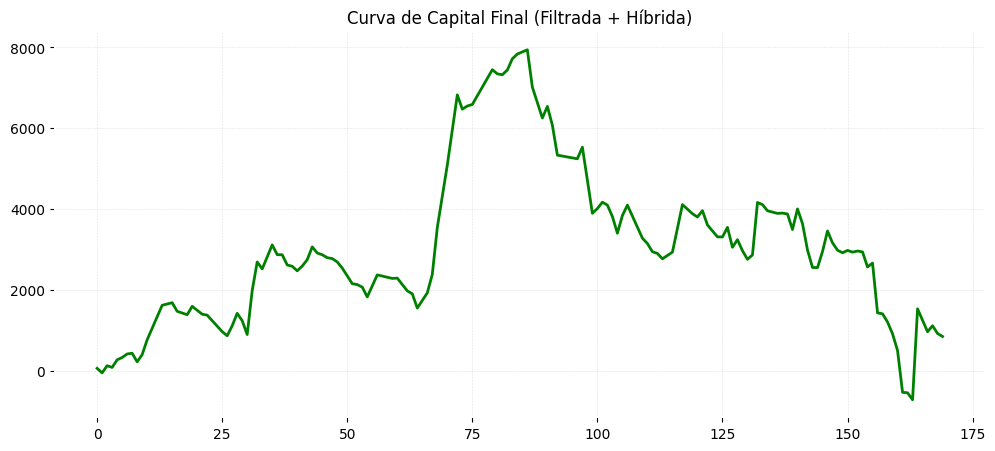

In [170]:
df_results = run_hybrid_backtest_v3(backtest_df, df_min, spec, sl_ticks=25, tp_ticks=60)

--- BACKTEST FINAL ---
Trades: 56 | Win Rate: 35.71%
Profit Neto: $1,830.00


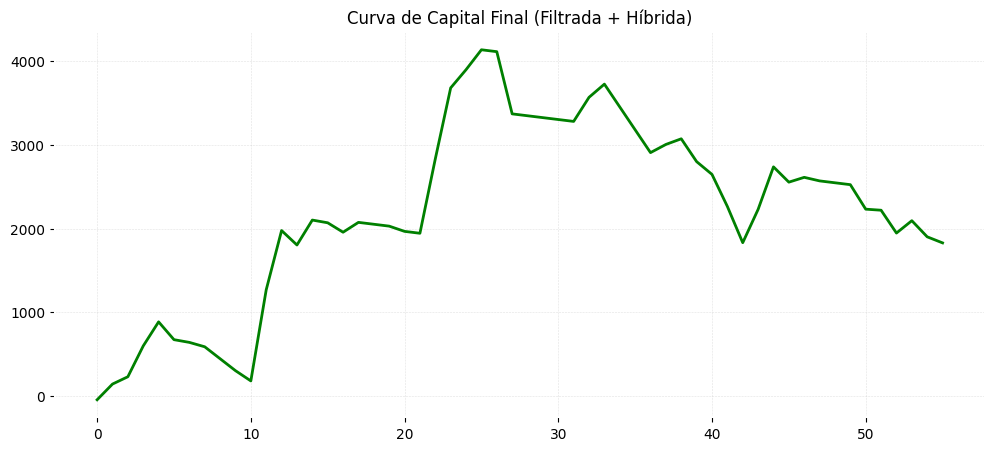

In [171]:
# 1. Alineamos las predicciones con el DataFrame de 5 minutos
backtest_df = df_features.iloc[-len(final_backtest_clean):].copy()
backtest_df['prob_buy'] = final_backtest_clean['prob_buy'].values
backtest_df['prob_sell'] = final_backtest_clean['prob_sell'].values
backtest_df['pred'] = final_backtest_clean['pred'].values

# 2. Lanzamos el Backtest Híbrido con los parámetros "de aire"
# SL=35 (darle margen al Oro) y TP=60 (buscar el beneficio real)
final_results_df = run_hybrid_backtest_v3(
    backtest_df, 
    df_min, # Tu DataFrame original de 1 minuto
    spec, 
    conf_buy=0.78, 
    conf_sell=0.65, 
    sl_ticks=25, 
    tp_ticks=60
)


In [172]:
# 1. Definimos los ganadores y perdedores
ganancias_brutas = final_results_df[final_results_df['pnl_usd'] > 0]['pnl_usd'].sum()
perdidas_brutas = abs(final_results_df[final_results_df['pnl_usd'] < 0]['pnl_usd'].sum())

# 2. Cálculo de Métricas
win_rate = (final_results_df['pnl_usd'] > 0).mean()
profit_factor = ganancias_brutas / perdidas_brutas if perdidas_brutas != 0 else float('inf')
avg_win = final_results_df[final_results_df['pnl_usd'] > 0]['pnl_usd'].mean()
avg_loss = abs(final_results_df[final_results_df['pnl_usd'] < 0]['pnl_usd'].mean())

print(f"--- ESTADÍSTICAS DEL FRANCOTIRADOR (56 TRADES) ---")
print(f"Win Rate: {win_rate:.2%}")
print(f"Profit Factor: {profit_factor:.2f}")
print(f"Ganancia Media: ${avg_win:.2f}")
print(f"Pérdida Media: ${avg_loss:.2f}")
print(f"Ratio R:R Real: {(avg_win/avg_loss):.2f}")

--- ESTADÍSTICAS DEL FRANCOTIRADOR (56 TRADES) ---
Win Rate: 35.71%
Profit Factor: 1.35
Ganancia Media: $352.50
Pérdida Media: $145.00
Ratio R:R Real: 2.43


--- BACKTEST FINAL ---
Trades: 11 | Win Rate: 36.36%
Profit Neto: $522.50


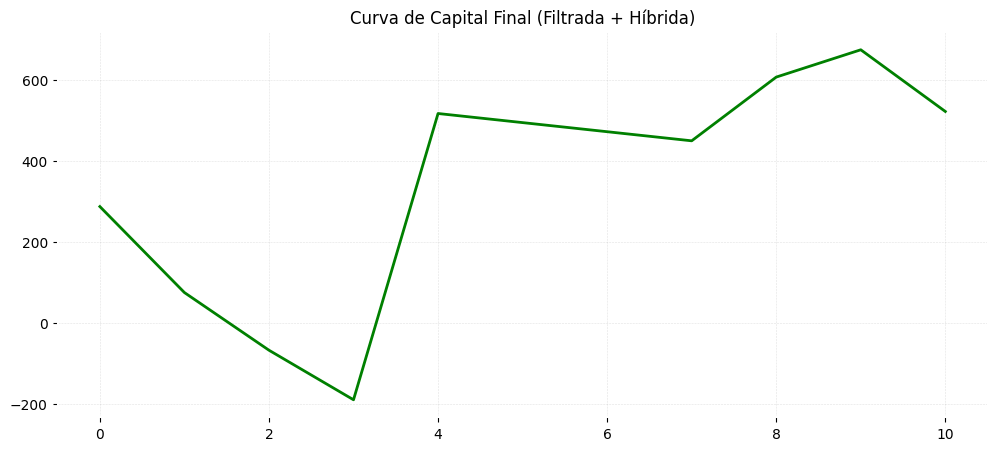

In [173]:
# NUEVOS PARÁMETROS PARA SUBIR EL PROFIT FACTOR
pnl_neto_ajustado = run_hybrid_backtest_v3(
    backtest_df, 
    df_min, 
    spec, 
    conf_buy=0.80,      # Más exigente aún
    conf_sell=0.68,     # Más exigente en ventas
    sl_ticks=20,        # ACORTAMOS el SL para perder menos (de 25 a 20)
    tp_ticks=55,        # Mantenemos un TP ambicioso
    min_range_ticks=18  # Subimos un poco el filtro de actividad
)


In [174]:
# 1. Definimos los ganadores y perdedores
ganancias_brutas = pnl_neto_ajustado[pnl_neto_ajustado['pnl_usd'] > 0]['pnl_usd'].sum()
perdidas_brutas = abs(pnl_neto_ajustado[pnl_neto_ajustado['pnl_usd'] < 0]['pnl_usd'].sum())

# 2. Cálculo de Métricas
win_rate = (pnl_neto_ajustado['pnl_usd'] > 0).mean()
profit_factor = ganancias_brutas / perdidas_brutas if perdidas_brutas != 0 else float('inf')
avg_win = pnl_neto_ajustado[pnl_neto_ajustado['pnl_usd'] > 0]['pnl_usd'].mean()
avg_loss = abs(pnl_neto_ajustado[pnl_neto_ajustado['pnl_usd'] < 0]['pnl_usd'].mean())

print(f"--- ESTADÍSTICAS DEL FRANCOTIRADOR (56 TRADES) ---")
print(f"Win Rate: {win_rate:.2%}")
print(f"Profit Factor: {profit_factor:.2f}")
print(f"Ganancia Media: ${avg_win:.2f}")
print(f"Pérdida Media: ${avg_loss:.2f}")
print(f"Ratio R:R Real: {(avg_win/avg_loss):.2f}")

--- ESTADÍSTICAS DEL FRANCOTIRADOR (56 TRADES) ---
Win Rate: 36.36%
Profit Factor: 1.75
Ganancia Media: $305.00
Pérdida Media: $99.64
Ratio R:R Real: 3.06


In [175]:
def monte_carlo_final(pnl_series, n_simulations=1000):
    """
    Desordena los 46 trades 1000 veces para ver el riesgo de ruina.
    """
    plt.figure(figsize=(10, 6))
    final_returns = []
    
    # Simular 1000 caminos posibles
    for _ in range(n_simulations):
        # Elegimos trades al azar con reemplazo
        sim_pnl = np.random.choice(pnl_series, size=len(pnl_series), replace=True)
        equity = np.cumsum(sim_pnl)
        plt.plot(equity, color='gray', alpha=0.1)
        final_returns.append(equity[-1])
    
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f"Monte Carlo: 1000 Variaciones de tu Estrategia ({len(pnl_series)} trades)")
    plt.ylabel("Dólares ($)")
    plt.show()
    
    prob_positive = (np.array(final_returns) > 0).mean()
    print(f"Probabilidad de terminar en POSITIVO: {prob_positive:.2%}")
    print(f"Peor escenario (Max DD sim): ${np.min(final_returns):,.2f}")

# EJECUCIÓN
# final_results_df['pnl_usd'] es la columna con los resultados netos de cada trade


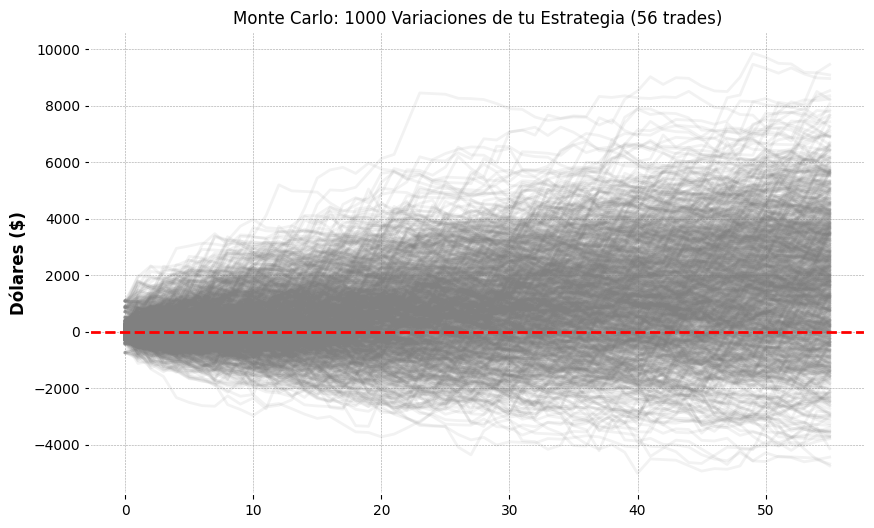

Probabilidad de terminar en POSITIVO: 77.70%
Peor escenario (Max DD sim): $-4,750.00


In [176]:
monte_carlo_final(final_results_df['pnl_usd'])


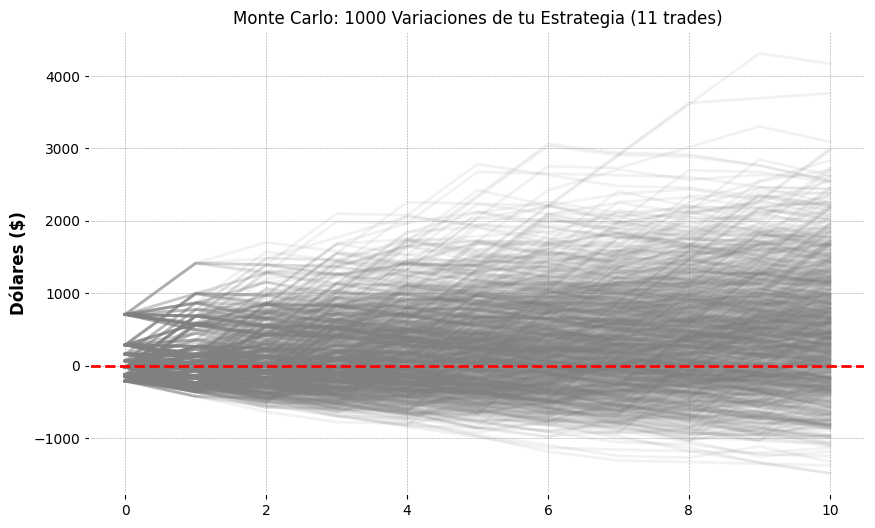

Probabilidad de terminar en POSITIVO: 71.10%
Peor escenario (Max DD sim): $-1,487.50


In [177]:
monte_carlo_final(pnl_neto_ajustado['pnl_usd'])

In [178]:
def run_hybrid_backtest_pro(df_signals, df_1min, spec, conf_buy=0.75, conf_sell=0.62, 
                            horizon_m=60, sl_ticks=30, tp_ticks=60, be_trigger=15):
    """
    Backtest Híbrido Avanzado:
    - Ejecución 1 min | Señales 5 min
    - Filtros: Tendencia (SMA), Rango (Volatilidad), Extensión (Distancia SMA)
    - Salidas: Stop Loss, Take Profit, Time Exit y Break-Even.
    """
    # Configuración de Activo desde tu SPEC
    tick_size = spec['tick_size']
    tick_value = spec['tick_value']
    cost_per_trade = 2.5 + (2.0 * tick_value) # Comisiones + 2 ticks (fricción)
    
    # --- 1. CÁLCULO DE FILTROS ---
    # Rango de la última hora (mide si hay actividad real)
    df_signals['range_1h'] = (df_signals['high'].rolling(12).max() - df_signals['low'].rolling(12).min()) / tick_size
    # Distancia a la media (evita entrar en el final del movimiento)
    df_signals['dist_sma'] = (df_signals['sma_20'] - df_signals['close']).abs() / tick_size
    
    # --- 2. FILTRADO DE SEÑALES ---
    # Filtro LONG: Tendencia + Rango Mínimo + No estirado
    mask_buy = (df_signals['prob_buy'] > conf_buy) & \
               (df_signals['close'] > df_signals['sma_20']) & \
               (df_signals['range_1h'] > 15) & \
               (df_signals['dist_sma'] < 15)
    
    # Filtro SHORT: Tendencia + Rango Mínimo + No estirado
    mask_sell = (df_signals['prob_sell'] > conf_sell) & \
                (df_signals['close'] < df_signals['sma_20']) & \
                (df_signals['range_1h'] > 15) & \
                (df_signals['dist_sma'] < 15)
    
    trades = df_signals[mask_buy | mask_sell].copy()
    
    # Preparar datos de 1 min
    df_1min_idx = df_1min.set_index('datetime').sort_index()
    results = []

    # --- 3. BUCLE DE EJECUCIÓN MINUTO A MINUTO ---
    for idx, row in trades.iterrows():
        entry_time, entry_p = row['datetime'], row['close']
        is_long = (row['pred'] == 2)
        
        # Niveles iniciales
        curr_sl = entry_p - (sl_ticks * tick_size) if is_long else entry_p + (sl_ticks * tick_size)
        tp_p = entry_p + (tp_ticks * tick_size) if is_long else entry_p - (tp_ticks * tick_size)
        
        # Ventana de 1 minuto (Horizonte de 1 hora)
        future_1min = df_1min_idx.loc[entry_time + pd.Timedelta(minutes=1) : 
                                      entry_time + pd.Timedelta(minutes=horizon_m)]
        
        pnl_ticks, exit_type, exit_time = None, 'Time', entry_time + pd.Timedelta(minutes=horizon_m)
        be_activated = False

        for t_1min, r_1min in future_1min.iterrows():
            # LÓGICA PARA LONG
            if is_long:
                # Activar Break-Even (Si el precio sube 15 ticks)
                if not be_activated and r_1min['high'] >= entry_p + (be_trigger * tick_size):
                    curr_sl = entry_p # Protegemos capital
                    be_activated = True
                
                # Comprobar Salidas
                if r_1min['low'] <= curr_sl:
                    pnl_ticks = 0 if be_activated else -sl_ticks
                    exit_type, exit_time = ('BE', t_1min) if be_activated else ('SL', t_1min)
                    break
                elif r_1min['high'] >= tp_p:
                    pnl_ticks, exit_type, exit_time = tp_ticks, 'TP', t_1min
                    break
            
            # LÓGICA PARA SHORT
            else:
                if not be_activated and r_1min['low'] <= entry_p - (be_trigger * tick_size):
                    curr_sl = entry_p # Protegemos capital
                    be_activated = True
                
                if r_1min['high'] >= curr_sl:
                    pnl_ticks = 0 if be_activated else -sl_ticks
                    exit_type, exit_time = ('BE', t_1min) if be_activated else ('SL', t_1min)
                    break
                elif r_1min['low'] <= tp_p:
                    pnl_ticks, exit_type, exit_time = tp_ticks, 'TP', t_1min
                    break
        
        # Si cerramos por tiempo
        if pnl_ticks is None:
            final_p = future_1min['close'].iloc[-1] if not future_1min.empty else entry_p
            pnl_ticks = (final_p - entry_p) / tick_size if is_long else (entry_p - final_p) / tick_size

        results.append({
            'entry_time': entry_time,
            'type': 'Long' if is_long else 'Short',
            'exit_reason': exit_type,
            'pnl_usd': (pnl_ticks * tick_value) - cost_per_trade,
            'pnl_ticks': pnl_ticks
        })

    return pd.DataFrame(results)


--- MÉTRICAS FINALES ---
Total Trades: 195
Win Rate: 24.62%
Profit Factor: 0.71
PnL Neto: $-4,687.50
Ratio Salidas: {'Time': 87, 'BE': 73, 'SL': 28, 'TP': 7}


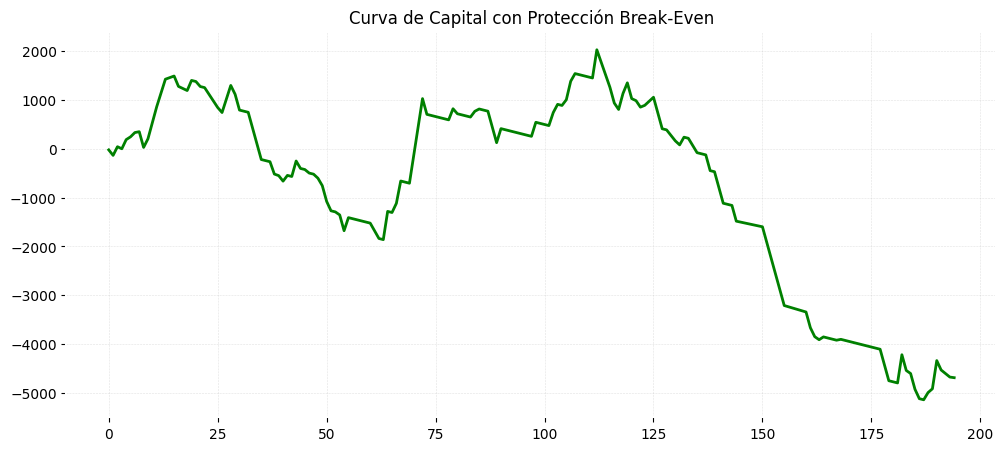

In [179]:
def plot_and_stats(res_df):
    if res_df.empty:
        print("No hubo trades con esta configuración.")
        return

    res_df['equity'] = res_df['pnl_usd'].cumsum()
    
    # Métricas
    wins = res_df[res_df['pnl_usd'] > 0]['pnl_usd'].sum()
    losses = abs(res_df[res_df['pnl_usd'] < 0]['pnl_usd'].sum())
    pf = wins / losses if losses != 0 else float('inf')
    wr = (res_df['pnl_usd'] > 0).mean()
    
    print(f"--- MÉTRICAS FINALES ---")
    print(f"Total Trades: {len(res_df)}")
    print(f"Win Rate: {wr:.2%}")
    print(f"Profit Factor: {pf:.2f}")
    print(f"PnL Neto: ${res_df['equity'].iloc[-1]:,.2f}")
    print(f"Ratio Salidas: {res_df['exit_reason'].value_counts().to_dict()}")

    plt.figure(figsize=(12, 5))
    res_df['equity'].plot(color='green', title='Curva de Capital con Protección Break-Even')
    plt.grid(alpha=0.3); plt.show()

# --- EJECUCIÓN FINAL ---
# 1. Alineamos datos (asegúrate de que df_features tenga las SMA calculadas)
backtest_df = df_features.iloc[-len(final_backtest_clean):].copy()
backtest_df['prob_buy'] = final_backtest_clean['prob_buy'].values
backtest_df['prob_sell'] = final_backtest_clean['prob_sell'].values
backtest_df['pred'] = final_backtest_clean['pred'].values

# 2. Corremos el backtest
df_results = run_hybrid_backtest_pro(
    backtest_df, 
    df_min, 
    spec, 
    conf_buy=0.76, 
    conf_sell=0.62, 
    sl_ticks=30,      # Damos aire al Oro
    tp_ticks=60,      # Buscamos beneficio real
    be_trigger=15     # Protegemos capital a los 15 ticks
)

# 3. Ver resultados
plot_and_stats(df_results)


Trade Short | Resultado: SL | PnL: -372.5$


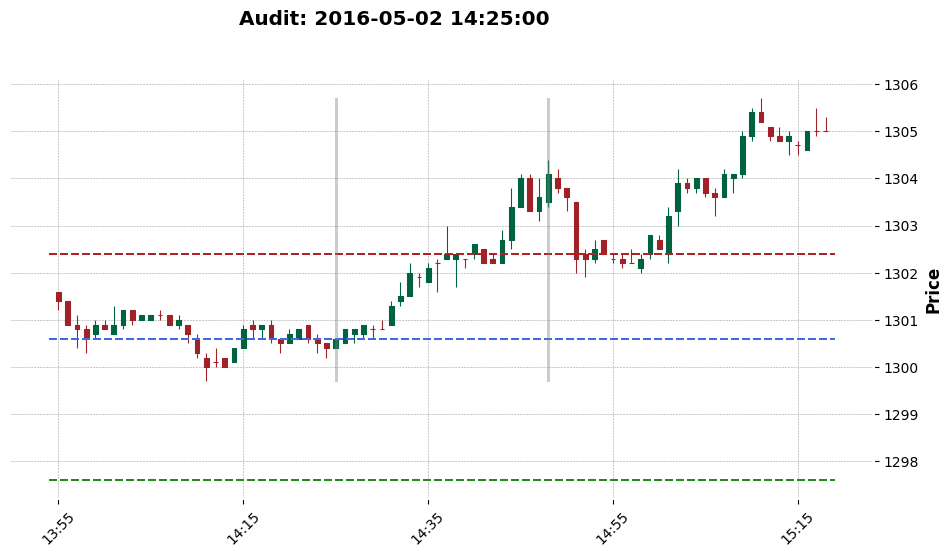

In [151]:
def audit_trade(df_1min, trade_res, spec, padding_mins=30):
    entry_t = trade_res['entry_time']
    exit_t = trade_res['exit_time']
    
    # 1. Extraer ventana de datos
    window = df_1min[(df_1min['datetime'] >= entry_t - pd.Timedelta(minutes=padding_mins)) & 
                     (df_1min['datetime'] <= exit_t + pd.Timedelta(minutes=padding_mins))].copy()
    window.set_index('datetime', inplace=True)
    
    # 2. Definir niveles
    entry_p = df_1min.loc[df_1min['datetime'] == entry_t, 'close'].values[0]
    # Calculamos niveles según el tipo de trade
    is_long = trade_res['type'] == 'Long'
    # Recuperamos ticks del resultado para pintar las líneas exactas
    sl_p = entry_p - (18 * spec['tick_size']) if is_long else entry_p + (18 * spec['tick_size'])
    tp_p = entry_p + (30 * spec['tick_size']) if is_long else entry_p - (30 * spec['tick_size'])

    # 3. Plot
    hlines = dict(hlines=[entry_p, sl_p, tp_p], colors=['#4169E1','#B22222','#228B22'], 
                  linestyle='--', linewidths=1.5)
    
    print(f"Trade {trade_res['type']} | Resultado: {trade_res['exit_reason']} | PnL: {trade_res['pnl_usd']}$")
    
    mpf.plot(window, type='candle', style='charles', title=f"Audit: {entry_t}",
             hlines=hlines, vlines=dict(vlines=[entry_t, exit_t], colors='gray', alpha=0.4),
             figsize=(12, 6))

# Ejemplo: Auditar el peor trade (el que más perdió)
worst_trade = df_results.sort_values('pnl_usd').iloc[0]
audit_trade(df_min, worst_trade, spec)
